In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [5]:
cagr_data = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] - group.iloc[0]["date"]).days
        / 365.25
    )

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_data.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr"]
)

cagr_df.sort_values(
    "cagr",
    ascending=False
).head()

,amfi_code,cagr
25,120505,0.328274
21,119598,0.324235
39,149324,0.322874
36,148569,0.319495
34,148567,0.309741


In [6]:
rf = 0.065

sharpe_data = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_vol = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - rf)
        / annual_vol
    )

    sharpe_data.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
sortino_data = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_data.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [8]:
drawdown_data = []

for code, group in nav.groupby("amfi_code"):

    group = group.copy()

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_data.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [9]:
print(cagr_df.shape)
print(sharpe_df.shape)
print(sortino_df.shape)
print(drawdown_df.shape)

(40, 2)
(40, 2)
(40, 2)
(40, 2)


In [10]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    sortino_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown
0,100016,0.026371,-0.201517,-0.351047,-0.247344
1,100025,0.044582,-0.567095,-0.941821,-0.043083
2,100033,0.301232,1.093699,1.829134,-0.162172
3,101206,0.235384,1.027213,1.799563,-0.112916
4,101207,0.079388,0.162661,0.276644,-0.354469


In [11]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["sortino_rank"] = scorecard["sortino_ratio"].rank(
    ascending=False
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [12]:
scorecard["fund_score"] = (
      scorecard["cagr_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.30
    + scorecard["sortino_rank"] * 0.20
    + scorecard["drawdown_rank"] * 0.20
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,drawdown_rank,fund_score
34,148567,0.309741,1.448291,2.385644,-0.112657,5.0,1.0,1.0,8.0,3.6
30,120843,0.309075,1.306744,2.364320,-0.129740,6.0,2.0,2.0,13.0,5.4
36,148569,0.319495,1.234930,2.146914,-0.163967,4.0,3.0,3.0,21.0,6.9
25,120505,0.328274,1.180101,2.029353,-0.181885,1.0,5.0,5.0,25.0,7.8
19,119551,0.258047,1.208267,2.140267,-0.150124,10.0,4.0,4.0,17.0,8.4
38,149323,0.295811,1.132122,1.875101,-0.172481,8.0,6.0,6.0,22.0,9.8
2,100033,0.301232,1.093699,1.829134,-0.162172,7.0,7.0,8.0,20.0,9.8
3,101206,0.235384,1.027213,1.799563,-0.112916,12.0,9.0,10.0,9.0,10.1
24,120504,0.232951,1.026524,1.805294,-0.125883,13.0,10.0,9.0,12.0,11.1
9,118632,0.240495,1.081659,1.850133,-0.174141,11.0,8.0,7.0,23.0,11.7


In [13]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [14]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,drawdown_rank,fund_score
34,148567,0.309741,1.448291,2.385644,-0.112657,5.0,1.0,1.0,8.0,3.6
30,120843,0.309075,1.306744,2.364320,-0.129740,6.0,2.0,2.0,13.0,5.4
36,148569,0.319495,1.234930,2.146914,-0.163967,4.0,3.0,3.0,21.0,6.9
25,120505,0.328274,1.180101,2.029353,-0.181885,1.0,5.0,5.0,25.0,7.8
19,119551,0.258047,1.208267,2.140267,-0.150124,10.0,4.0,4.0,17.0,8.4


In [15]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [16]:
benchmark = pd.read_csv("../data/10_benchmark_indices.csv")

print(benchmark.shape)
print(benchmark.columns)

benchmark.head()

(8050, 3)
Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [18]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [19]:
fund_returns = nav[
    ["amfi_code", "date", "daily_return"]
].copy()

merged = fund_returns.merge(
    nifty100[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [20]:
from scipy.stats import linregress

In [21]:
alpha_beta = []

for code, group in merged.groupby(
    "amfi_code"
):

    group = group.dropna()

    if len(group) < 30:
        continue

    result = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    beta = result.slope

    alpha = (
        result.intercept * 252
    )

    alpha_beta.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [23]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head()

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830


In [24]:
tracking_error = []

for code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    active_return = (
        group["daily_return"]
        - group["benchmark_return"]
    )

    te = (
        active_return.std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.sort_values(
    "tracking_error"
).head()

,amfi_code,tracking_error
5,101208,0.128957
27,120507,0.129044
31,120844,0.129046
1,100025,0.134535
13,118636,0.134758


In [25]:
top5 = scorecard.head(5)["amfi_code"].tolist()

print(top5)

[148567, 120843, 148569, 120505, 119551]


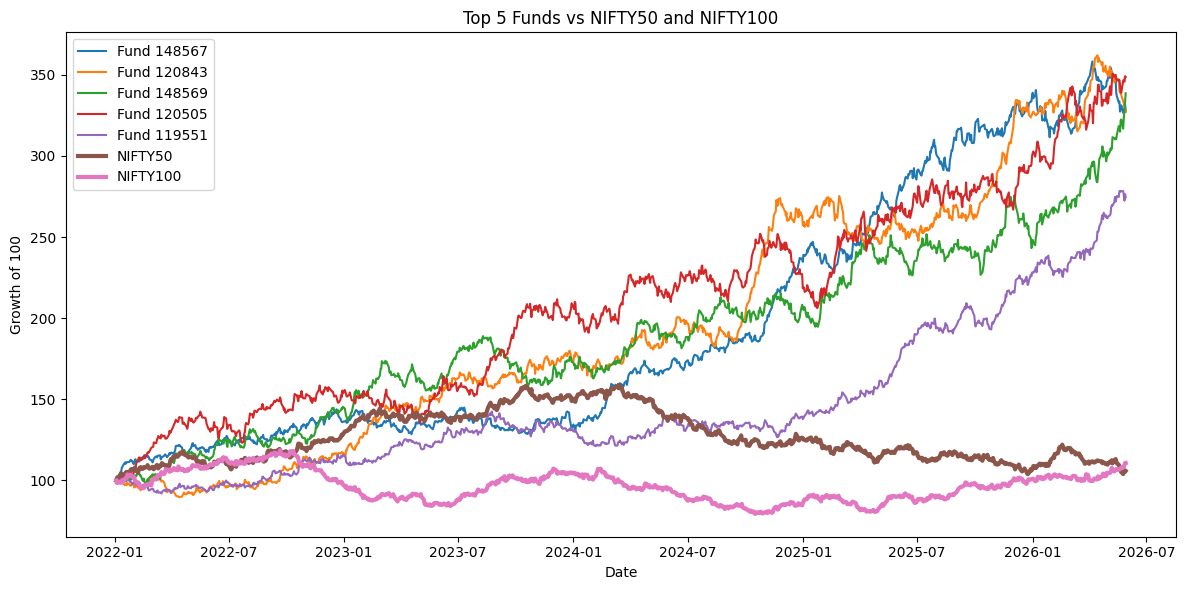

In [26]:
# Top 5 funds
top5 = [148567, 120843, 148569, 120505, 119551]

# Fund NAV data
top_funds_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

# Normalize fund NAVs to start at 100
top_funds_nav["cum_index"] = (
    top_funds_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Benchmark data
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["cum_index"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["cum_index"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

plt.figure(figsize=(12,6))

# Plot funds
for code in top5:
    temp = top_funds_nav[
        top_funds_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["cum_index"],
        label=f"Fund {code}"
    )

# Plot benchmarks
plt.plot(
    nifty50["date"],
    nifty50["cum_index"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["cum_index"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100")
plt.ylabel("Growth of 100")
plt.xlabel("Date")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [27]:
import os

os.path.exists(
    "../reports/benchmark_comparison.png"
)

True